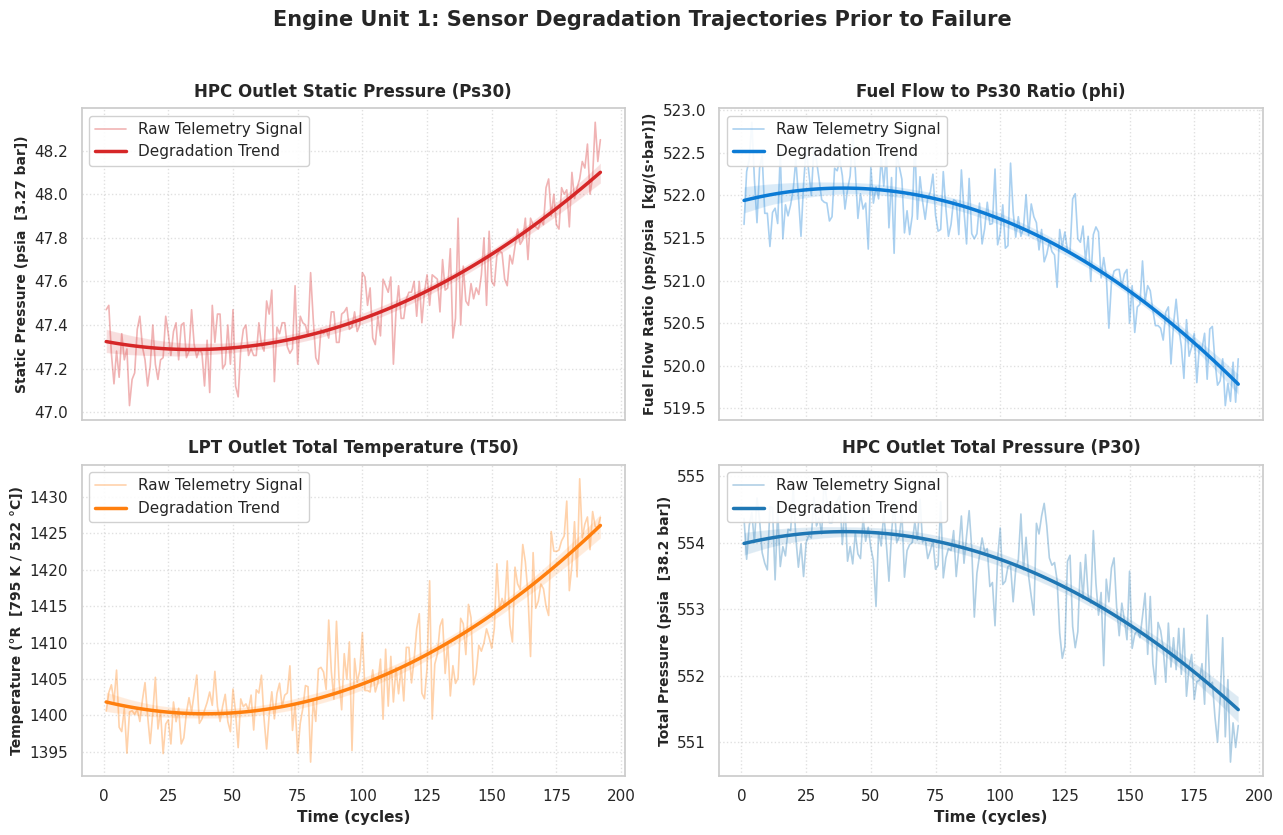

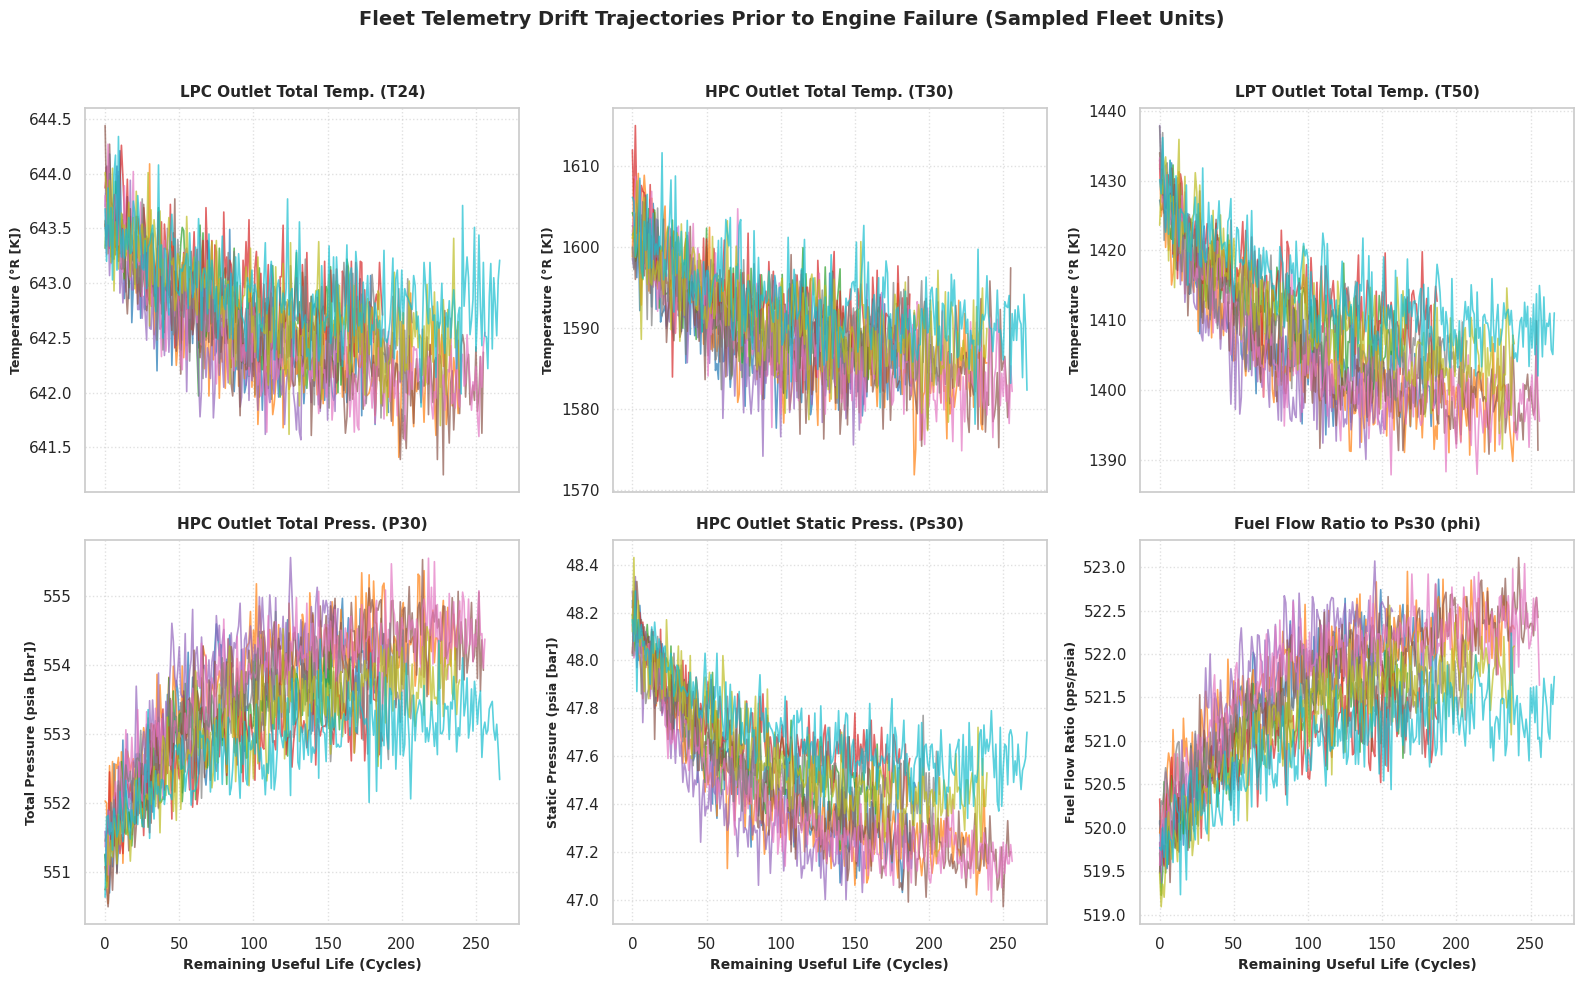

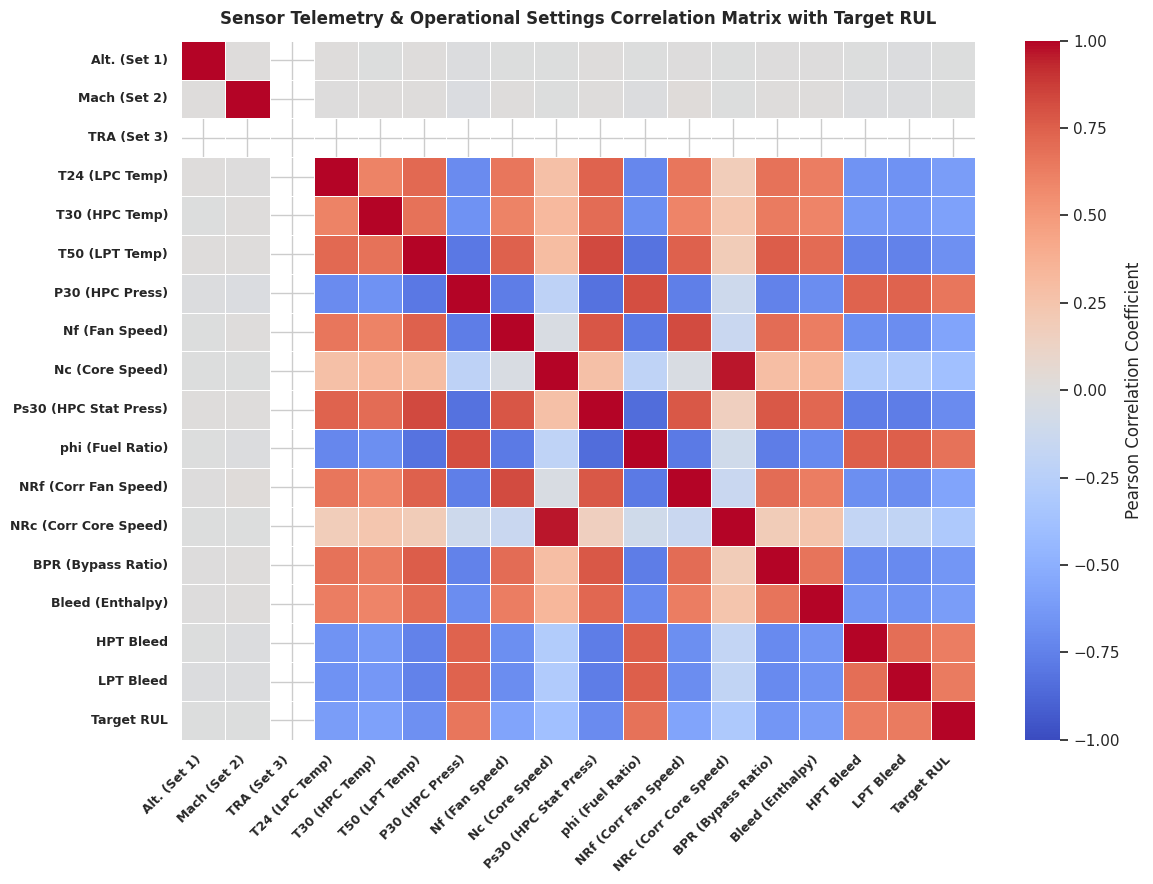

Engineered Dataset Shape: (20631, 36)
Engineered dataset successfully saved to '/Users/maharhandi/Desktop/Maha/DATA_ANALYST/Portfolio_Tracking/data_analysis_portfolio/project-2/data/processed/cmapss_engineered.csv'

--- Feature Multicollinearity Assessment (VIF) ---
  Feature        VIF
setting_3 558.517141
      s_9  17.844745
     s_14  17.255013
     s_11   5.997833
     s_12   5.266260
      s_8   4.712011
     s_13   4.700370
      s_4   4.578736
      s_7   4.329507
     s_15   3.297481
     s_21   3.108975
     s_20   3.060971
      s_2   2.638850
     s_17   2.559503
      s_3   2.289617
setting_1   1.001737
setting_2   1.000775


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Global Plot Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.family": "sans-serif"})

# Base Directory Setup
BASE_DIR = "***/data_analysis_portfolio/project-2"
DATA_PATH = os.path.join(BASE_DIR, "data/processed/cmapss_cleaned.csv")
FIGURES_DIR = os.path.join(BASE_DIR, "reports/figures")
OUTPUT_DATA_PATH = os.path.join(BASE_DIR, "data/processed/cmapss_engineered.csv")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(os.path.dirname(OUTPUT_DATA_PATH), exist_ok=True)

# 1. Load Cleaned Dataset
df = pd.read_csv(DATA_PATH)
df_cleaned = df
unit_1 = df[df["unit_nr"] == 1].copy()

# 2. Configure Sensor Metadata & Build 2x2 Grid Plot (Unit 1 Trajectories)
sensor_meta_unit1 = {
    "s_11": {
        "title": "HPC Outlet Static Pressure (Ps30)",
        "dimension": "Static Pressure",
        "unit": "psia  [3.27 bar]",
        "color": "#D62728",
    },
    "s_12": {
        "title": "Fuel Flow to Ps30 Ratio (phi)",
        "dimension": "Fuel Flow Ratio",
        "unit": "pps/psia  [kg/(s·bar)]",
        "color": "#0C7BD5",
    },
    "s_4": {
        "title": "LPT Outlet Total Temperature (T50)",
        "dimension": "Temperature",
        "unit": "°R  [795 K / 522 °C]",
        "color": "#FF7F0E",
    },
    "s_7": {
        "title": "HPC Outlet Total Pressure (P30)",
        "dimension": "Total Pressure",
        "unit": "psia  [38.2 bar]",
        "color": "#1F77B4",
    },
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
fig.suptitle(
    "Engine Unit 1: Sensor Degradation Trajectories Prior to Failure",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

plot_grid = [
    ("s_11", axes[0, 0]),
    ("s_12", axes[0, 1]),
    ("s_4", axes[1, 0]),
    ("s_7", axes[1, 1]),
]

for sensor_id, ax in plot_grid:
    meta = sensor_meta_unit1[sensor_id]

    sns.lineplot(
        data=unit_1,
        x="time_cycles",
        y=sensor_id,
        ax=ax,
        color=meta["color"],
        alpha=0.35,
        linewidth=1.2,
        label="Raw Telemetry Signal",
    )

    sns.regplot(
        data=unit_1,
        x="time_cycles",
        y=sensor_id,
        ax=ax,
        scatter=False,
        order=2,
        line_kws={"color": meta["color"], "linewidth": 2.5},
        label="Degradation Trend",
    )

    ax.set_title(meta["title"], fontsize=12, fontweight="bold", pad=8)
    ax.set_ylabel(
        f"{meta['dimension']} ({meta['unit']})", fontsize=10, fontweight="bold"
    )
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9)

for ax in axes[1, :]:
    ax.set_xlabel("Time (cycles)", fontsize=11, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(FIGURES_DIR, "degradation_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

# 3. Fleet Telemetry Drift Trajectories (Sampled Fleet Units)
sensor_meta_fleet = {
    "s_2": {
        "title": "LPC Outlet Total Temp. (T24)",
        "y_label": "Temperature (°R [K])",
    },
    "s_3": {
        "title": "HPC Outlet Total Temp. (T30)",
        "y_label": "Temperature (°R [K])",
    },
    "s_4": {
        "title": "LPT Outlet Total Temp. (T50)",
        "y_label": "Temperature (°R [K])",
    },
    "s_7": {
        "title": "HPC Outlet Total Press. (P30)",
        "y_label": "Total Pressure (psia [bar])",
    },
    "s_11": {
        "title": "HPC Outlet Static Press. (Ps30)",
        "y_label": "Static Pressure (psia [bar])",
    },
    "s_12": {
        "title": "Fuel Flow Ratio to Ps30 (phi)",
        "y_label": "Fuel Flow Ratio (pps/psia)",
    },
}

sample_units = df["unit_nr"].drop_duplicates().sample(10, random_state=42)
sample_df = df[df["unit_nr"].isin(sample_units)]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True)
axes = axes.flatten()

sensors_to_plot = ["s_2", "s_3", "s_4", "s_7", "s_11", "s_12"]

for idx, sensor_id in enumerate(sensors_to_plot):
    meta = sensor_meta_fleet[sensor_id]
    ax = axes[idx]

    sns.lineplot(
        data=sample_df,
        x="RUL",
        y=sensor_id,
        hue="unit_nr",
        palette="tab10",
        alpha=0.7,
        linewidth=1.2,
        ax=ax,
        legend=False,
    )

    ax.invert_xaxis()
    ax.set_title(meta["title"], fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel(meta["y_label"], fontsize=9, fontweight="bold")
    ax.set_xlabel("Remaining Useful Life (Cycles)", fontsize=10, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.6)

fig.suptitle(
    "Fleet Telemetry Drift Trajectories Prior to Engine Failure (Sampled Fleet Units)",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(FIGURES_DIR, "degradation_trajectories.png"), dpi=300, bbox_inches="tight")
plt.show()

# 4. Correlation Matrix Heatmap
feature_rename_map = {
    "setting_1": "Alt. (Set 1)",
    "setting_2": "Mach (Set 2)",
    "setting_3": "TRA (Set 3)",
    "s_2": "T24 (LPC Temp)",
    "s_3": "T30 (HPC Temp)",
    "s_4": "T50 (LPT Temp)",
    "s_7": "P30 (HPC Press)",
    "s_8": "Nf (Fan Speed)",
    "s_9": "Nc (Core Speed)",
    "s_11": "Ps30 (HPC Stat Press)",
    "s_12": "phi (Fuel Ratio)",
    "s_13": "NRf (Corr Fan Speed)",
    "s_14": "NRc (Corr Core Speed)",
    "s_15": "BPR (Bypass Ratio)",
    "s_17": "Bleed (Enthalpy)",
    "s_20": "HPT Bleed",
    "s_21": "LPT Bleed",
    "RUL": "Target RUL",
}

df_corr = df.drop(columns=["unit_nr", "time_cycles"], errors="ignore").rename(columns=feature_rename_map)
corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient"},
)

plt.title(
    "Sensor Telemetry & Operational Settings Correlation Matrix with Target RUL",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.xticks(rotation=45, ha="right", fontsize=9, fontweight="bold")
plt.yticks(fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sensor_drift_correlations.png"), dpi=300, bbox_inches="tight")
plt.show()

# 5. Feature Engineering (Rolling Statistics)
def engineer_features(data, window_size=5):
    """Engineers rolling temporal statistics per engine unit."""
    df_feat = data.copy()
    key_sensors = ["s_2", "s_3", "s_4", "s_7", "s_11", "s_12", "s_15", "s_17"]

    for sensor in key_sensors:
        if sensor in df_feat.columns:
            rolled = df_feat.groupby("unit_nr")[sensor].rolling(window_size, min_periods=1)
            df_feat[f"{sensor}_roll_mean"] = rolled.mean().values
            df_feat[f"{sensor}_roll_std"] = rolled.std().fillna(0).values

    return df_feat

df_engineered = engineer_features(df, window_size=5)
print(f"Engineered Dataset Shape: {df_engineered.shape}")

# 6. Feature Normalization / Scaling & Saving Data
meta_cols = ["unit_nr", "time_cycles", "RUL"]
feature_cols = [c for c in df_engineered.columns if c not in meta_cols]

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df_engineered[feature_cols])

df_scaled = pd.DataFrame(scaled_features, columns=feature_cols, index=df_engineered.index)
for col in meta_cols:
    if col in df_engineered.columns:
        df_scaled[col] = df_engineered[col]

df_scaled.to_csv(OUTPUT_DATA_PATH, index=False)
print(f"Engineered dataset successfully saved to '{OUTPUT_DATA_PATH}'")

# 7. Variance Inflation Factor (VIF) Assessment
raw_features = [c for c in feature_cols if "roll" not in c]
sample_features = df_scaled[raw_features].dropna()

vif_matrix = sample_features.values + 1e-5
vif_data = pd.DataFrame({
    "Feature": raw_features,
    "VIF": [variance_inflation_factor(vif_matrix, i) for i in range(len(raw_features))]
})

print("\n--- Feature Multicollinearity Assessment (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))